# Blocked vs. Interspersed presentation of tasks
Comparing the normal presentation of tasks (seperated in blocks) 
with the MDTB-style interspersed presentation of tasks.

In [5]:

import numpy as np
from numpy.linalg import inv,eig,eigh
import PcmPy as pcm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from numpy import sqrt


In [15]:
instr_code = 90 # Instruction condition code

def var_contrasts(X,reg_ind):
    """ Calculate the variance you would get for contrasts on beta-estimates
    from a design matrix X the regressors indicating different conditions
    We do this seperately for all contrast against rest
    and all the pairwise contrasts between conditions.
    """
    conv_beta = inv(X.T@X)
    reg_ind[reg_ind==instr_code] = 0
    # CI are the contrast against rest
    CI = pcm.matrix.indicator(reg_ind,positive=True).T
    CI = CI / CI.sum(axis=1,keepdims=True)
    # CP are the pairwise contrast
    CP = pcm.matrix.pairwise_contrast(reg_ind,positive=True)
    var_i = np.diag(CI@conv_beta@CI.T)
    var_p = np.diag(CP@conv_beta@CP.T)
    return var_i,var_p

In [66]:
def make_design_matrix(reg_id=[[1, 2], [3, 4], [5, 6]],
                       p_rest=0.2,
                       T=100,
                       instruction_TR=0):  # Default: no instruction time
    """Make a design matrix with the conditions indicated in reg_id,
    rest phases with probability p_rest, and optional instruction periods."""
    
    num_part = len(reg_id)  # Number of runs
    part_v = np.kron(np.arange(num_part), np.ones((T,)))  # Run indices
     # Add instruction condition to each run 
    if instruction_TR > 0:
        reg_id = [r + [instr_code] for r in reg_id] 
    reg_ind = np.concatenate(reg_id)

    # Get the partition index for the columns of the design matrix
    part_ind = [np.ones(len(r)) * i for i, r in enumerate(reg_id)]
    part_ind = np.concatenate(part_ind)

    X = np.zeros((T * num_part, reg_ind.shape[0]))
    cv = []
    for i in range(num_part):
        num_cond = len(reg_id[i])
        if instruction_TR > 0:
            num_reg = len(reg_id[i])
            num_cond = num_reg - 1

        # Deduct instruction TRs if instruction_time > 0
        instruction_TRs = instruction_TR * num_cond
        lc = int((T - T * p_rest - instruction_TRs) // num_cond)
        lr = T - lc * num_cond - instruction_TRs

        # Build the condition vector
        if instruction_TR > 0:
            ccvv = np.array(reg_id[i][:-1])  # Task conditions
        else:
            ccvv = np.array(reg_id[i])
        cond_v = np.kron(ccvv, np.ones((lc,)))  # Task periods
        cond_v = np.concatenate((cond_v, np.ones((instruction_TRs,)) * instr_code))  # Instruction periods
        cond_v = np.concatenate((cond_v, np.zeros((lr,))))  # Rest periods
        cv.append(cond_v)

        # Fill the design matrix
        row = np.where(part_v == i)[0]
        col = np.where(part_ind == i)[0]
        X[np.ix_(row, col)] = pcm.matrix.indicator(cond_v, positive=True)

    cond_v = np.concatenate(cv)
    X = np.concatenate([X, pcm.indicator(part_v)], axis=1)
    reg_ind = np.concatenate([reg_ind, np.zeros(num_part)])

    # Use the first condition to get a measure of TR per condition
    lc = (cond_v > 0).sum()  # Count task time
    lr = (cond_v == 0).sum()  # Count rest time
    return X, cond_v, part_v, reg_ind, part_ind, lc, lr




def compare_designs(design=None,
                    T=90,
                    p_rest=[0.7,0.6,1/2,1/2.5,1/3,1/4,1/5,1/6,1/7,1/8,1/9,1/11,1/15],
                    instruction_time=5):
    """Compare blocked and interspersed designs with optional instruction times."""
    if design is None:
        design = [[[1, 2], [3, 4], [5, 6]],  # Blocked design
                  [[1, 2, 3, 4, 5, 6]] * 3]  # Interspersed design

    # get unique indices from one of the designs
    n_unique = len(np.unique(np.concatenate(design[0])))
    n_contrasts = n_unique*(n_unique-1)//2

    ci = np.zeros(n_contrasts,dtype=bool)
    ci[[0,5]]=True # THese are the within-run contrast
    
    DF = pd.DataFrame()
    for rp in p_rest:
        for i, d in enumerate(design):
            include_instruction = instruction_time if i == 1 else 0  # Only add instructions to interspersed
            X, _, _, reg, _, lc, lr = make_design_matrix(d, rp, T, include_instruction)
            vari, varp = var_contrasts(X, reg)
            df = {'Design': [i],
                  'length_rest': [lr],
                  'p_rest': [lr / (T * len(d))],
                  'length_cond': [lc],
                  'std_vs_rest': sqrt(vari.mean()),
                  'std_pairwise': sqrt(varp.mean()),
                  'std_pairwisew': sqrt(varp[ci].mean()),
                  'std_pairwiseb': sqrt(varp[~ci].mean())}
            print(f'rp {rp},design{i}')
            DF = pd.concat([DF, pd.DataFrame(df)], ignore_index=True)
    return DF


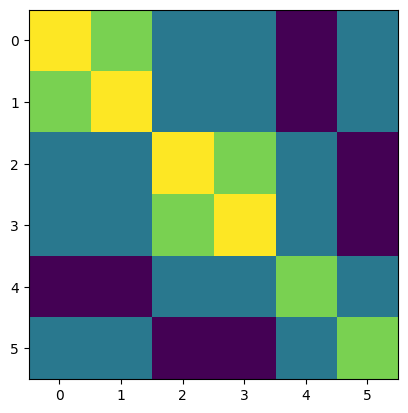

In [67]:
# For checking - this is covariance matrix between
# Estimates from a blocked design
design_b=[[1,2],[3,4]] # Blocked design
X1,_,_,reg1,_,_,_ = make_design_matrix(design_b,instruction_TR=0)
conv_beta = inv(X1.T@X1)
plt.imshow(conv_beta)

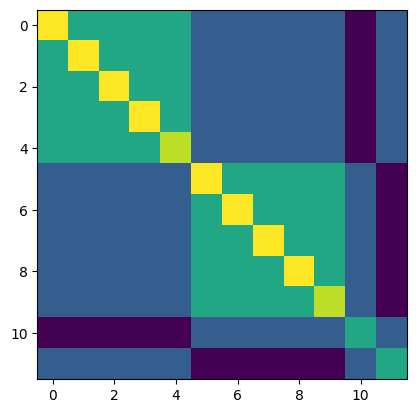

In [68]:
# THis is the covariance matrix for the regressors
# For an interspersed design
design_i=[[1,2,3,4]]*2 # Intersperse design
X2,_,_,reg2,_,_,_ = make_design_matrix(design_i,instruction_TR=5)
conv_beta = inv(X2.T@X2)
plt.imshow(conv_beta)

In [69]:
# Now we are calculating the std of the
# contrast against rest
# contrast of different conditions (within runs)
# contrast of different conditions (between runs)

T=300
numpart = len(design_b)
DF = compare_designs([design_b,design_i],T)
DF


rp 0.7,design0
rp 0.7,design1
rp 0.6,design0
rp 0.6,design1
rp 0.5,design0
rp 0.5,design1
rp 0.4,design0
rp 0.4,design1
rp 0.3333333333333333,design0
rp 0.3333333333333333,design1
rp 0.25,design0
rp 0.25,design1
rp 0.2,design0
rp 0.2,design1
rp 0.16666666666666666,design0
rp 0.16666666666666666,design1
rp 0.14285714285714285,design0
rp 0.14285714285714285,design1
rp 0.125,design0
rp 0.125,design1
rp 0.1111111111111111,design0
rp 0.1111111111111111,design1
rp 0.09090909090909091,design0
rp 0.09090909090909091,design1
rp 0.06666666666666667,design0
rp 0.06666666666666667,design1


,Design,length_rest,p_rest,length_cond,std_vs_rest,std_pairwise,std_pairwisew,std_pairwiseb
0,0,420,0.700000,180,0.164268,0.225374,0.210819,0.232311
1,1,424,0.706667,176,0.178242,0.242536,0.242536,0.242536
2,0,360,0.600000,240,0.149071,0.201843,0.182574,0.210819
3,1,360,0.600000,240,0.150923,0.200000,0.200000,0.200000
4,0,300,0.500000,300,0.141421,0.188562,0.163299,0.200000
5,1,304,0.506667,296,0.137530,0.176777,0.176777,0.176777
6,0,240,0.400000,360,0.139443,0.182574,0.149071,0.197203
7,1,240,0.400000,360,0.129099,0.158114,0.158114,0.158114
8,0,200,0.333333,400,0.141421,0.182574,0.141421,0.200000
9,1,200,0.333333,400,0.126930,0.149071,0.149071,0.149071


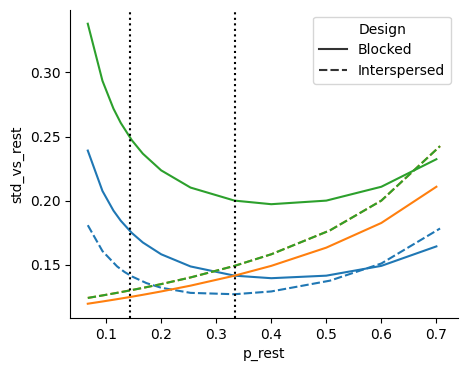

In [70]:
DF['Design'] = DF['Design'].replace({0: 'Blocked', 1: 'Interspersed'})
# Make the plot.
plt.figure(figsize=(5,4))
sb.lineplot(data=DF,x='p_rest',y='std_vs_rest',style='Design')
sb.lineplot(data=DF,x='p_rest',y='std_pairwisew',style='Design',legend=False)
sb.lineplot(data=DF,x='p_rest',y='std_pairwiseb',style='Design',legend=False)
plt.axvline(1/7,color='black',linestyle=':')
plt.axvline(1/3,color='black',linestyle=':')

# max the y axis
# Remove the box around the plot
sb.despine()



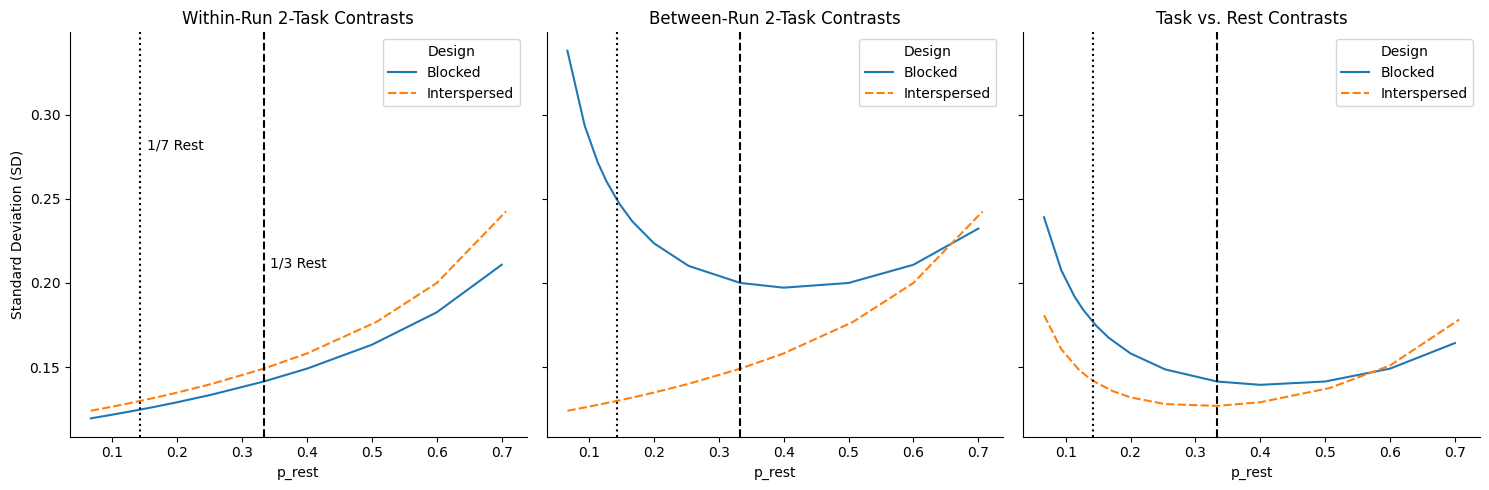

In [72]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot within-run contrasts
sb.lineplot(data=DF, x='p_rest', y='std_pairwisew', hue='Design', style='Design',
            markers=False, ax=axs[0])
axs[0].set_title('Within-Run 2-Task Contrasts')
axs[0].set_ylabel('Standard Deviation (SD)')

# Plot between-run contrasts
sb.lineplot(data=DF, x='p_rest', y='std_pairwiseb', hue='Design', style='Design',
            markers=False, ax=axs[1])
axs[1].set_title('Between-Run 2-Task Contrasts')
axs[1].set_ylabel('')

# Plot contrast vs. rest
sb.lineplot(data=DF, x='p_rest', y='std_vs_rest', hue='Design', style='Design',
            markers=False, ax=axs[2])
axs[2].set_title('Task vs. Rest Contrasts')
axs[2].set_ylabel('')

for ax in axs:
    ax.axvline(1/7, color='black', linestyle=':', label='1/7 Rest')
    ax.axvline(1/3, color='black', linestyle='--', label='1/3 Rest')

# Annotate the lines
axs[0].text(1/7 + 0.01, axs[0].get_ylim()[1] * 0.8, '1/7 Rest', color='black', fontsize=10)
axs[0].text(1/3 + 0.01, axs[0].get_ylim()[1] * 0.6, '1/3 Rest', color='black', fontsize=10)

plt.tight_layout()

# Remove top and right spines
sb.despine(fig=fig)

# Show the plot
plt.show()
